In [40]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 24.0 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [1]:
#Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import textwrap

In [2]:
#Read in the data
port_return = pd.read_excel(
    "portfolio_return.xlsx",
    header = 0,
    parse_dates = ["Date"]
)
port_return["Date"] = pd.to_datetime(port_return["Date"], format = "%m/%d/%Y")
port_return["Year"] = port_return["Date"].dt.year #adding a year column to group by year later
print(port_return.head(10))

fama_french = pd.read_excel(
    "fama_french.xlsx",
    header = 0,
    parse_dates = ["d"]
)
fama_french.rename(columns = {"d": "Date"}, inplace = True)
print(fama_french.head(10))

        Date  Weighted Return Tc  Year
0 2001-01-02            0.122225  2001
1 2001-01-03            0.048400  2001
2 2001-01-04           -0.062711  2001
3 2001-01-05            0.023720  2001
4 2001-01-08            0.018585  2001
5 2001-01-09            0.005078  2001
6 2001-01-10            0.007549  2001
7 2001-01-11           -0.011376  2001
8 2001-01-12           -0.012677  2001
9 2001-01-16           -0.001744  2001
        Date   mktrf     smb     hml   rf     umd
0 2004-01-02 -0.0017  0.0081  0.0042  0.0  0.0002
1 2004-01-05  0.0120  0.0040  0.0001  0.0  0.0055
2 2004-01-06  0.0020  0.0009  0.0027  0.0  0.0071
3 2004-01-07  0.0034  0.0059 -0.0008  0.0  0.0046
4 2004-01-08  0.0045  0.0030  0.0072  0.0  0.0031
5 2004-01-09 -0.0072 -0.0002  0.0029  0.0  0.0041
6 2004-01-12  0.0057  0.0091  0.0013  0.0  0.0038
7 2004-01-13 -0.0051  0.0018  0.0009  0.0 -0.0002
8 2004-01-14  0.0080 -0.0007  0.0044  0.0  0.0018
9 2004-01-15  0.0015  0.0004 -0.0028  0.0  0.0011


In [3]:
#PART ONE: PERFORMANCE MODELING

#1A
modeling_df = port_return[(port_return["Year"] >= 2004) & (port_return["Year"] <= 2006)]

perf_report = modeling_df.groupby("Year")["Weighted Return Tc"].agg(
    ann_return = lambda x: x.mean() * 252,
    ann_vol = lambda x: x.std() * np.sqrt(252),
)

perf_report["Sharpe"] = perf_report["ann_return"] / perf_report["ann_vol"]
print(perf_report)

print(f'Overall Annualized Return: {modeling_df["Weighted Return Tc"].mean() * 252}')
print(f'Overall Annualized Volatility: {modeling_df["Weighted Return Tc"].std() * np.sqrt(252)}')
print(f'Overall Sharpe Ratio: {(modeling_df["Weighted Return Tc"].mean() * np.sqrt(252)) / modeling_df["Weighted Return Tc"].std()}')

      ann_return   ann_vol    Sharpe
Year                                
2004    0.699385  0.152606  4.582948
2005    0.731797  0.161342  4.535686
2006    0.440309  0.148467  2.965707
Overall Annualized Return: 0.6240733346116267
Overall Annualized Volatility: 0.1542534891543237
Overall Sharpe Ratio: 4.045764786476042


In [4]:
#1B and 1C

#Create merged dataset of daily weighted returns (net TC) and Fama French factors
merge_df = pd.merge(port_return, fama_french, on = "Date", how = "outer", indicator = True)
strategy_df = merge_df[merge_df["_merge"] == "both"]
strategy_df = strategy_df[["Date", "Weighted Return Tc", "Year", "mktrf", "smb", "hml", "rf", "umd"]]
# print(strategy_df.head(10))

#CAPM Regression
strategy_df["Excess Return"] = strategy_df["Weighted Return Tc"] - strategy_df["rf"]
X = strategy_df["mktrf"]
X = sm.add_constant(X)

Y = strategy_df["Excess Return"]

model = sm.OLS(Y, X).fit()
print(model.summary())

#Fama French Regression
X = strategy_df[["mktrf", "smb", "hml", "umd"]]
X = sm.add_constant(X)

Y = strategy_df["Excess Return"]

model = sm.OLS(Y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          Excess Return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.688
Date:                Tue, 10 Mar 2026   Prob (F-statistic):              0.194
Time:                        17:04:01   Log-Likelihood:                 2428.2
No. Observations:                 755   AIC:                            -4852.
Df Residuals:                     753   BIC:                            -4843.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.000      6.603      0.0

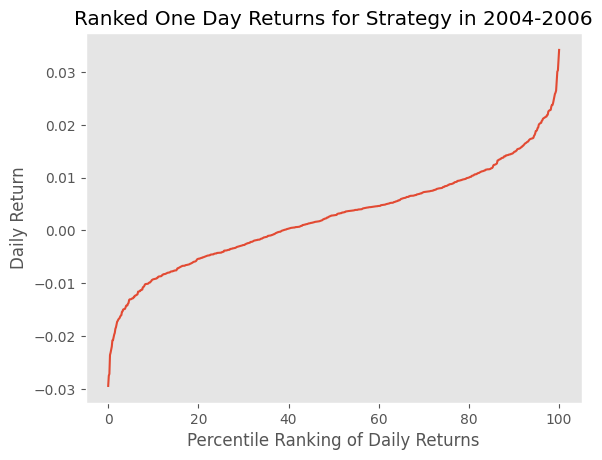

Percentage of days that were winners: 61.19205298013245
Percentage of days that were losers: 38.80794701986755
The median daily return of winners is 0.007016423361511213
The median daily return of losers is -0.00582963733168726


In [8]:
#1D

#Sort the returns around a percentile ranking from lowest to highest returns
sorted_returns = modeling_df["Weighted Return Tc"].sort_values().reset_index(drop = True)
percentile = np.linspace(0, 100, len(sorted_returns))

plt.style.use("ggplot")
plt.figure()
plt.plot(percentile, sorted_returns)
plt.grid()
plt.xlabel("Percentile Ranking of Daily Returns")
plt.ylabel("Daily Return")
plt.title("Ranked One Day Returns for Strategy in 2004-2006")
plt.show()

#Percentage of winners and losers
print(f'Percentage of days that were winners: {100 * (sorted_returns > 0).sum() / len(sorted_returns)}')
print(f'Percentage of days that were losers: {100 * (sorted_returns < 0).sum() / len(sorted_returns)}')

#Median return of winners and losers
print(f'The median daily return of winners is {sorted_returns[sorted_returns > 0].median()}')
print(f'The median daily return of losers is {sorted_returns[sorted_returns < 0].median()}')

In [ ]:
#PART TWO: PERFORMANCE ATTRIBUTION

#Read in the data for Part 2

#Data on the weighted returns (net tc) for long and short sub-portfolios
long_short_return = pd.read_excel(
    "long_short_return.xlsx",
    header = 0,
    parse_dates = ["Date"]
)
long_short_return["Date"] = pd.to_datetime(long_short_return["Date"], format = "%m/%d/%Y")
long_short_return["Year"] = long_short_return["Date"].dt.year
# print(long_short_return.head(10))

#Fama French data in 2007-2009
fama_french_perf = pd.read_excel(
    "fama_french_2007-2009.xlsx",
    header = 0,
    parse_dates = ["d"]
)
fama_french_perf.rename(columns = {"d": "Date"}, inplace = True)
# print(fama_french_perf.head(10))

#Stock Weighted Return Data by ticker for trade dates
stock_return = pd.read_excel(
    "stock_return.xlsx",
    header = 0,
    parse_dates = ["Date"]
)

#Stock Weights by ticker for trade dates
stock_weights = pd.read_excel(
    "stock_weights.xlsx",
    header = 0,
    parse_dates = ["Date"]
)
stock_weights = stock_weights.set_index("Date")
stock_weights.index = pd.to_datetime(stock_weights.index).normalize()

#Sector Return Data for SIC and GICS - already just for 2009
sic_return = pd.read_excel(
    "sector_return.xlsx",
    sheet_name = "sic",
    header = 0
)

gics_return = pd.read_excel(
    "sector_return.xlsx",
    sheet_name = "gics",
    header = 0
)


In [10]:
#2A
attribution_df = port_return[(port_return["Date"] >= "2007-01-01") & (port_return["Date"] < "2010-01-01")]

#Overall Strategy Report
att_report = attribution_df.groupby("Year")["Weighted Return Tc"].agg(
    ann_return = lambda x: x.mean() * 252,
    ann_vol = lambda x: x.std() * np.sqrt(252),
)
att_report["Sharpe"] = att_report["ann_return"] / att_report["ann_vol"]
print(att_report)

print(f'Overall Annualized Return: {attribution_df["Weighted Return Tc"].mean() * 252}')
print(f'Overall Annualized Volatility: {attribution_df["Weighted Return Tc"].std() * np.sqrt(252)}')
print(f'Overall Sharpe Ratio: {(attribution_df["Weighted Return Tc"].mean() * np.sqrt(252)) / attribution_df["Weighted Return Tc"].std()}')
print("\n")

#Long and Short Strategy Report
long_short_df = long_short_return[(long_short_return["Date"] >= "2007-01-01") & (long_short_return["Date"] < "2010-01-01")]

long_report = long_short_df.groupby("Year")["Long"].agg(
    ann_return = lambda x: x.mean() * 252,
    ann_vol = lambda x: x.std() * np.sqrt(252),
)
long_report["Sharpe"] = long_report["ann_return"] / long_report["ann_vol"]
print(long_report)
print(f'Long Portfolio Annualized Return: {long_short_df["Long"].mean() * 252}')
print(f'Long Portfolio Annualized Volatility: {long_short_df["Long"].std() * np.sqrt(252)}')
print(f'Long Portfolio Sharpe Ratio: {(long_short_df["Long"].mean() * np.sqrt(252)) / long_short_df["Long"].std()}')
print("\n")

short_report = long_short_df.groupby("Year")["Short"].agg(
    ann_return = lambda x: x.mean() * 252,
    ann_vol = lambda x: x.std() * np.sqrt(252),
)
short_report["Sharpe"] = short_report["ann_return"] / short_report["ann_vol"]
print(short_report)
print(f'Short Portfolio Annualized Return: {long_short_df["Short"].mean() * 252}')
print(f'Short Portfolio Annualized Volatility: {long_short_df["Short"].std() * np.sqrt(252)}')
print(f'Short Portfolio Sharpe Ratio: {(long_short_df["Short"].mean() * np.sqrt(252)) / long_short_df["Short"].std()}')
print("\n")


      ann_return   ann_vol    Sharpe
Year                                
2007   -0.136600  0.192477 -0.709695
2008    0.604363  0.422931  1.428986
2009    0.310905  0.378036  0.822420
Overall Annualized Return: 0.2605361317497789
Overall Annualized Volatility: 0.3461929185882665
Overall Sharpe Ratio: 0.7525749885705757


      ann_return   ann_vol    Sharpe
Year                                
2007   -0.495525  0.216047 -2.293594
2008   -0.743360  0.491567 -1.512225
2009    0.110886  0.430874  0.257352
Long Portfolio Annualized Return: -0.3763274085381727
Long Portfolio Annualized Volatility: 0.3979208799706481
Long Portfolio Sharpe Ratio: -0.9457342589459791


      ann_return   ann_vol    Sharpe
Year                                
2007    0.358925  0.171992  2.086870
2008    1.347723  0.422104  3.192872
2009    0.200018  0.397728  0.502902
Short Portfolio Annualized Return: 0.6368635402879514
Short Portfolio Annualized Volatility: 0.35054310299415853
Short Portfolio Sharpe Ratio: 1

In [11]:
#2B
merge_df2 = pd.merge(port_return, fama_french_perf, how = "outer", indicator = True)
merge_df2 = merge_df2[merge_df2["_merge"] == "both"]
strategy_df2 = merge_df2[["Date", "Weighted Return Tc", "mktrf", "rf"]]

strategy_df2["Excess Return"] = strategy_df2["Weighted Return Tc"] - strategy_df2["rf"]

X2 = strategy_df2["mktrf"]
X2 = sm.add_constant(X2)
Y2 = strategy_df2["Excess Return"]

model2 = sm.OLS(Y2, X2).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:          Excess Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.02129
Date:                Tue, 10 Mar 2026   Prob (F-statistic):              0.884
Time:                        17:05:35   Log-Likelihood:                 1819.6
No. Observations:                 756   AIC:                            -3635.
Df Residuals:                     754   BIC:                            -3626.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      1.195      0.2

In [13]:
#2C
num_weighted_ret_df = stock_return.select_dtypes(include = "number")

#Best winner
best_row = num_weighted_ret_df.stack().idxmax()
best_weight_ret = num_weighted_ret_df.stack().max()
best_date = pd.to_datetime(stock_return.loc[best_row[0], "Date"]).normalize()
best_ticker = best_row[1]
best_weight = stock_weights.loc[best_date, best_ticker]
best_simple_ret = best_weight_ret / best_weight

print(f'Best Single-Day Performance: {best_ticker} on {best_date} with simple return {best_simple_ret} and portfolio weight {best_weight}')

#Worst loser
worst_row = num_weighted_ret_df.stack().idxmin()
worst_weight_ret = num_weighted_ret_df.stack().min()
worst_date = pd.to_datetime(stock_return.loc[worst_row[0], "Date"]).normalize()
worst_ticker = worst_row[1]
worst_weight = stock_weights.loc[worst_date, worst_ticker]
worst_simple_ret = worst_weight_ret / worst_weight

print(f'Worst Single-Day Performance: {worst_ticker} on {worst_date} with simple return {worst_simple_ret} and portfolio weight {worst_weight}')

#Checking that the weights are in decimal form
print(stock_weights.sum(axis=1).describe())
print(stock_weights.abs().sum(axis=1).describe())

Best Single-Day Performance: VOXW on 2009-03-18 00:00:00 with simple return 2.994982273553991 and portfolio weight 0.014705882352
Worst Single-Day Performance: LEH on 2008-09-15 00:00:00 with simple return -2.8561292015825384 and portfolio weight 0.014084507042
count    2.263000e+03
mean    -3.233963e-03
std      8.241175e-03
min     -5.405405e-02
25%     -9.259259e-03
50%      0.000000e+00
75%      3.469447e-18
max      2.985075e-02
dtype: float64
count    2263.000000
mean        1.994150
std         0.008670
min         1.934579
25%         1.989474
50%         2.000000
75%         2.000000
max         2.000000
dtype: float64


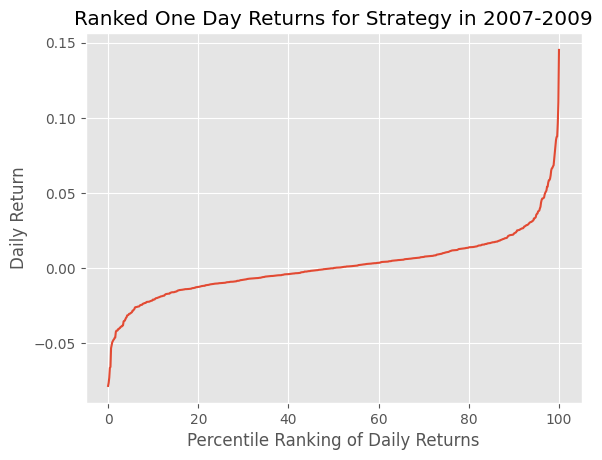

Percentage of days that were winners: 49.6031746031746
Percentage of days that were losers: 50.3968253968254
The median daily return of winners is 0.010456130470292112
The median daily return of losers is -0.010113837442524937


In [31]:
#2D
sorted_returns2 = attribution_df["Weighted Return Tc"].sort_values().reset_index(drop = True)
percentile = np.linspace(0, 100, len(sorted_returns2))

plt.figure()
plt.plot(percentile, sorted_returns2)
plt.xlabel("Percentile Ranking of Daily Returns")
plt.ylabel("Daily Return")
plt.title("Ranked One Day Returns for Strategy in 2007-2009")
plt.show()

#Percentage of winners and losers
print(f'Percentage of days that were winners: {100 * (sorted_returns2 > 0).sum() / len(sorted_returns2)}')
print(f'Percentage of days that were losers: {100 * (sorted_returns2 < 0).sum() / len(sorted_returns2)}')

#Median return of winners and losers
print(f'The median daily return of winners is {sorted_returns2[sorted_returns2 > 0].median()}')
print(f'The median daily return of losers is {sorted_returns2[sorted_returns2 < 0].median()}')

                                                 SIC  Weighted Return Tc
0                 Agriculture, Forestry, and Fishing           -0.001464
1                                       Construction            0.049770
2                Finance, Insurance, and Real Estate           -0.094547
3                                      Manufacturing            0.335133
4                                             Mining           -0.034806
5                                       Retail Trade            0.024474
6                                           Services            0.078193
7  Transportation, Communications, Electric, Gas,...           -0.033689
8                                    Wholesale Trade           -0.012160
SIC sector with largest total return: Manufacturing
Largest total return: 0.3351332256817607
Fraction of Strategy Total: 1.0779294073069772




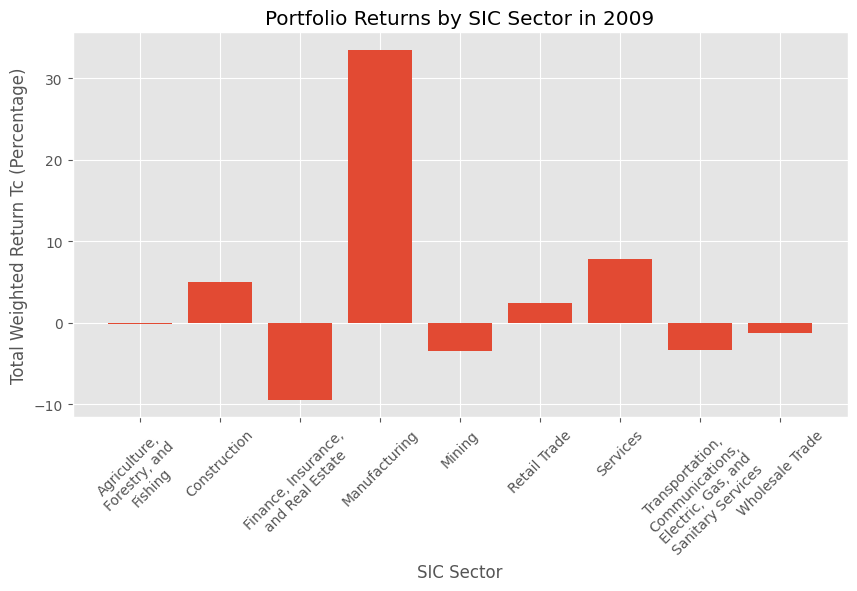

                          GICS  Weighted Return Tc
0                          NaN            0.215556
1                       Energy           -0.027907
2                    Materials           -0.007311
3                  Industrials            0.035667
4       Consumer Discretionary           -0.084798
5             Consumer Staples            0.054054
6                  Health Care            0.157223
7                   Financials           -0.079094
8       Information Technology            0.043106
9   Telecommunication Services            0.001548
10                   Utilities            0.002860


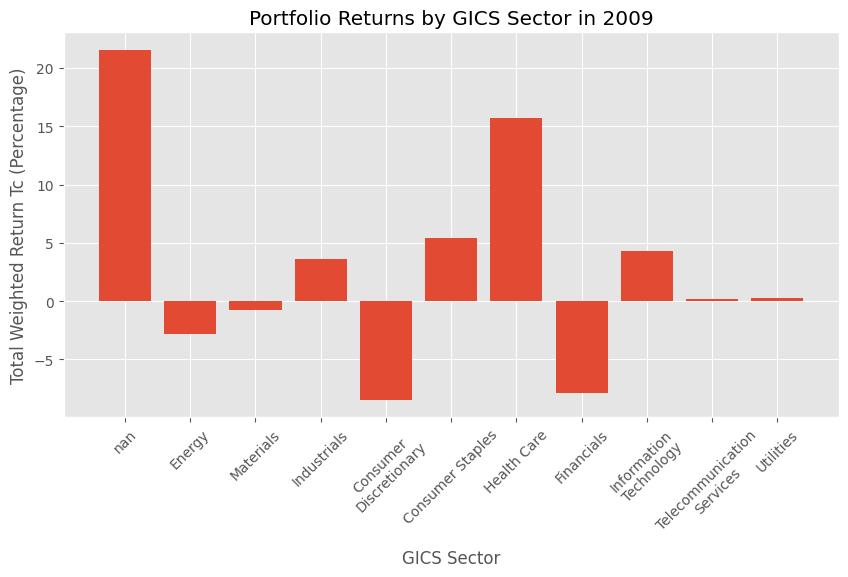

GICS sector with largest total return: nan
Largest total return: 0.21555644208609276
Fraction of Strategy Total: 0.6933201785241803


In [15]:
#2F and 2G

#SIC
print(sic_return)

print(f'SIC sector with largest total return: {sic_return.loc[sic_return["Weighted Return Tc"].abs().idxmax()]["SIC"]}')
print(f'Largest total return: {sic_return["Weighted Return Tc"].max()}')
print(f'Fraction of Strategy Total: {sic_return["Weighted Return Tc"].max() / sic_return["Weighted Return Tc"].sum()}')
print("\n")

wrapped_labels = [
    "\n".join(textwrap.wrap(label, 20))
    for label in sic_return["SIC"]
]

plt.figure(figsize = (10, 5))
plt.bar(
    wrapped_labels,
    sic_return["Weighted Return Tc"] * 100
)

plt.title("Portfolio Returns by SIC Sector in 2009")
plt.ylabel("Total Weighted Return Tc (Percentage)")
plt.xlabel("SIC Sector")
plt.xticks(rotation = 45)
plt.show()

#GICS
print(gics_return)

wrapped_labels2 = [
    "\n".join(textwrap.wrap(str(label), 20))
    for label in gics_return["GICS"]
]

plt.figure(figsize = (10, 5))
plt.bar(
    wrapped_labels2,
    gics_return["Weighted Return Tc"] * 100
)

plt.title("Portfolio Returns by GICS Sector in 2009")
plt.ylabel("Total Weighted Return Tc (Percentage)")
plt.xlabel("GICS Sector")
plt.xticks(rotation = 45)
plt.show()

print(f'GICS sector with largest total return: {gics_return.loc[gics_return["Weighted Return Tc"].abs().idxmax()]["GICS"]}')
print(f'Largest total return: {gics_return["Weighted Return Tc"].max()}')
print(f'Fraction of Strategy Total: {gics_return["Weighted Return Tc"].max() / gics_return["Weighted Return Tc"].sum()}')

In [ ]:
#PART THREE: RISK MEASUREMENT

#Download the data

#GICS weight exposures
gics_weights = pd.read_excel(
    "gics_weights.xlsx",
    header = 0,
    parse_dates = ["Date"]
)
gics_weights = gics_weights[(gics_weights["Date"] >= "2007-01-01") & (gics_weights["Date"] < "2010-01-01")]
# print(gics_weights.head(10))

#GICS Financials Data
financial_return = pd.read_excel(
    "financials_return.xlsx",
    header = 0,
    parse_dates = ["Date"]
)
financial_return["Date"] = pd.to_datetime(financial_return["Date"], format = "%m/%d/%Y")
financial_return = financial_return[(financial_return["Date"] >= "2007-01-01") & (financial_return["Date"] < "2010-01-01")]
# print(financial_return.head(10))


           Date      Long     Short  Grand Total
1507 2007-01-03  0.036145 -0.108434    -0.072289
1508 2007-01-04  0.024096 -0.072289    -0.048193
1509 2007-01-05  0.060241 -0.036145     0.024096
1510 2007-01-08  0.048193 -0.048193     0.000000
1511 2007-01-09  0.072289 -0.084337    -0.012048
1512 2007-01-10  0.048193 -0.072289    -0.024096
1513 2007-01-11  0.072289 -0.036145     0.036145
1514 2007-01-12  0.036145       NaN     0.036145
1515 2007-01-16  0.012048 -0.024096    -0.012048
1516 2007-01-17  0.036145 -0.084337    -0.048193


In [ ]:
#3A
col_list = ['NA', 'Energy', 'Materials', 'Industrials',
       'Consumer Discretionary', 'Consumer Staples', 'Health Care',
       'Financials', 'Information Technology', 'Telecommunication Services',
       'Utilities']
sectors = gics_weights[col_list]

#Highest Net Exposure
print(sectors.max())

#Lowest Net Exposure
print(sectors.min())

cols = sectors.columns[(sectors.max() <= 0.10) & (sectors.min() >= -0.10)]
print(f'Sectors that stayed within 10% of net portfolio weight: {cols}')

NA                            0.309859
Energy                        0.309859
Materials                     0.169014
Industrials                   0.141026
Consumer Discretionary        0.194030
Consumer Staples              0.092308
Health Care                   0.227848
Financials                    0.333333
Information Technology        0.240964
Telecommunication Services    0.040000
Utilities                     0.028571
dtype: float64
NA                           -0.200000
Energy                       -0.197183
Materials                    -0.126761
Industrials                  -0.189873
Consumer Discretionary       -0.240000
Consumer Staples             -0.080000
Health Care                  -0.222222
Financials                   -0.487179
Information Technology       -0.227848
Telecommunication Services   -0.051282
Utilities                    -0.028169
dtype: float64
Sectors that stayed within 10% of net portfolio weight: Index(['Consumer Staples', 'Telecommunication Services',

In [114]:
#3B
print(attribution_df[(attribution_df["Date"] == "2008-09-12")])

           Date  Weighted Return Tc  Year
1934 2008-09-12            0.001317  2008


In [ ]:
#3C (don't run more than once)
stock_return = stock_return[(stock_return["Date"] == "2008-09-15")]
stock_return = stock_return.select_dtypes(include = "number")
stock_return = stock_return.abs()

In [ ]:
#3C Continued (so it can be run repeatedly)
print(f'{stock_return.stack().idxmax()[1]} contributed {round(100 * stock_return.stack().max() / stock_return.stack().sum(), 2)}% (in absolute value) to the portfolio return with an absolute value return of {stock_return.stack().max()} on 9/15/2008.')

LEH contributed 19.38% (in absolute value) to the portfolio return with an absolute value return of 0.0402271718525511 on 9/15/2008.


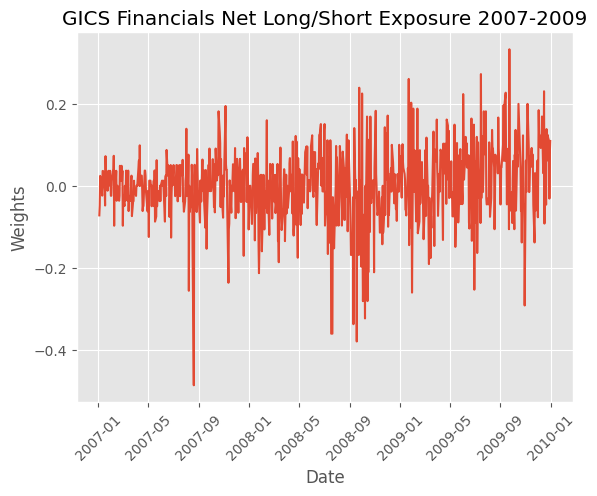

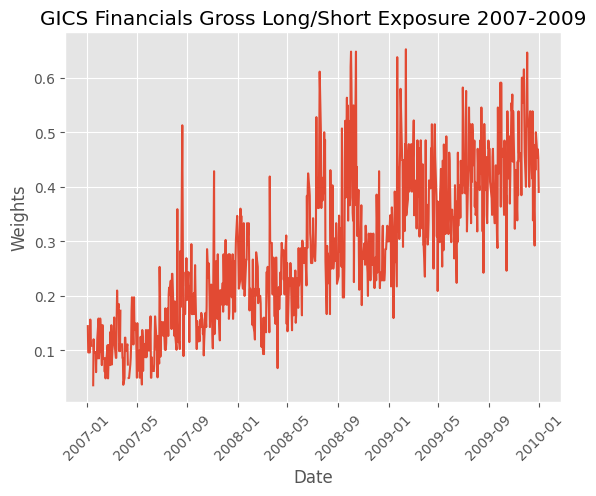

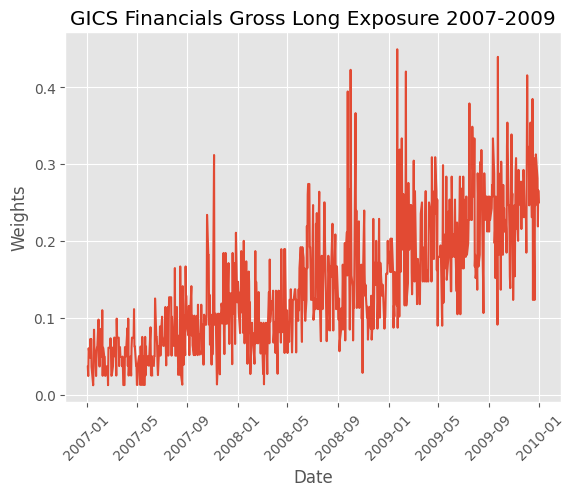

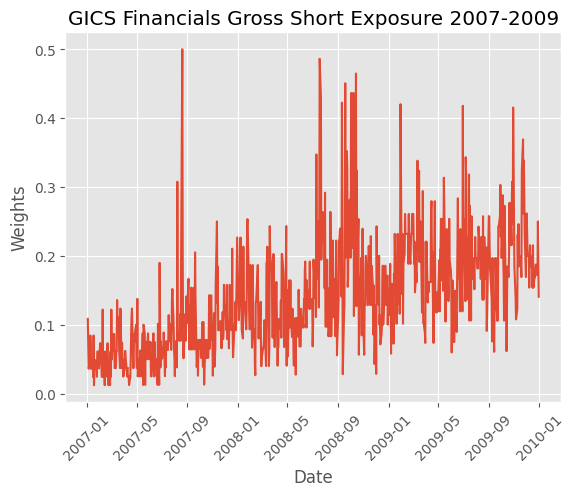

In [138]:
#3D

#Plotting the Net Long/Short Exposure
plt.figure()
plt.plot(financial_return["Date"], financial_return["Grand Total"])
plt.title("GICS Financials Net Long/Short Exposure 2007-2009")
plt.xlabel("Date")
plt.ylabel("Weights")
plt.xticks(rotation = 45)
plt.show()

#Plotting the Gross Long/Short Exposure
plt.figure()
plt.plot(financial_return["Date"], financial_return["Long"] + financial_return["Short"].abs())
plt.title("GICS Financials Gross Long/Short Exposure 2007-2009")
plt.xlabel("Date")
plt.ylabel("Weights")
plt.xticks(rotation = 45)
plt.show()

#Plotting the Gross Long Exposure
plt.figure()
plt.plot(financial_return["Date"], financial_return["Long"])
plt.title("GICS Financials Gross Long Exposure 2007-2009")
plt.xlabel("Date")
plt.ylabel("Weights")
plt.xticks(rotation = 45)
plt.show()

#Plotting the Gross Short Exposure
plt.figure()
plt.plot(financial_return["Date"], financial_return["Short"].abs())
plt.title("GICS Financials Gross Short Exposure 2007-2009")
plt.xlabel("Date")
plt.ylabel("Weights")
plt.xticks(rotation = 45)
plt.show()

In [5]:
#PART FOUR: CORRELATION DYNAMICS

#Download 2008-2009 and 2019-2020 SQL Data from view_fact_index
index_0809 = pd.read_excel(
    "index_var_2008-2009.xlsx",
    header = 0,
    parse_dates = ["d"]
)
index_0809["d"] = pd.to_datetime(index_0809["d"])
print(index_0809.head(10))

index_1920 = pd.read_excel(
    "index_var_2019-2020.xlsx",
    header = 0,
    parse_dates = ["d"]
)
index_1920["d"] = pd.to_datetime(index_1920["d"])
print(index_1920.head(10))

           d  id_bench   var_021   var_063  num  weight_total    return  \
0 2008-01-02         5  0.027174  0.032754   29      0.977484 -0.016129   
1 2008-01-03         5  0.027094  0.032688   29      0.977469  0.000949   
2 2008-01-04         5  0.031264  0.034085   29      0.977855 -0.018844   
3 2008-01-07         5  0.027983  0.033878   29      0.979018  0.003320   
4 2008-01-08         5  0.027923  0.035075   29      0.979983 -0.016096   
5 2008-01-09         5  0.030578  0.035361   29      0.980053  0.010863   
6 2008-01-10         5  0.031096  0.035750   29      0.980116  0.009147   
7 2008-01-11         5  0.030092  0.037005   29      0.979540 -0.019340   
8 2008-01-14         5  0.033017  0.037731   29      0.979070  0.012890   
9 2008-01-15         5  0.036954  0.039249   29      0.979719 -0.020714   

   var0_021  var1_021  var0_063  var1_063  
0  0.002004  0.048359  0.002421  0.058753  
1  0.001972  0.047321  0.002412  0.058535  
2  0.002137  0.051198  0.002470  0.060052 

In [6]:
#Average Implied Correlation - using simplified formula derived in class
index_0809["avg_corr"] = (index_0809["var_063"] - index_0809["var0_063"]) / (index_0809["var1_063"] - index_0809["var0_063"])
index_1920["avg_corr"] = (index_1920["var_063"] - index_1920["var0_063"]) / (index_1920["var1_063"] - index_1920["var0_063"])

#Index Realized Volatility
index_0809["real_vol"] = np.sqrt(index_0809["var_063"])
index_1920["real_vol"] = np.sqrt(index_1920["var_063"])

#Index Volatility 0
index_0809["vol_0"] = np.sqrt(index_0809["var0_063"])
index_1920["vol_0"] = np.sqrt(index_1920["var0_063"])

#Index Volatility 1
index_0809["vol_1"] = np.sqrt(index_0809["var1_063"])
index_1920["vol_1"] = np.sqrt(index_1920["var1_063"])

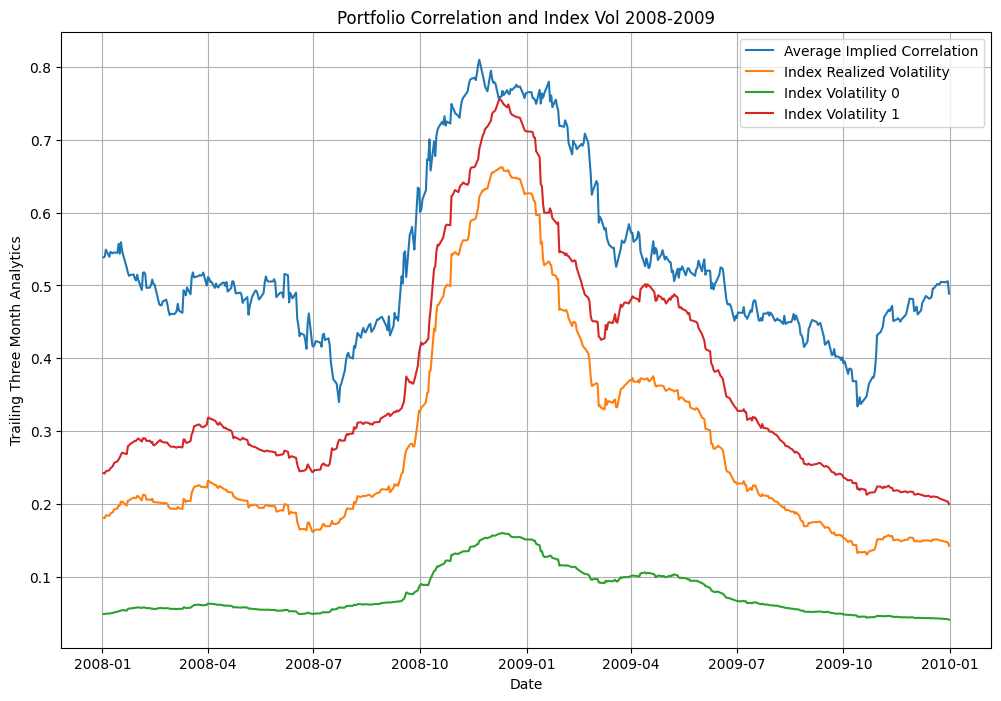

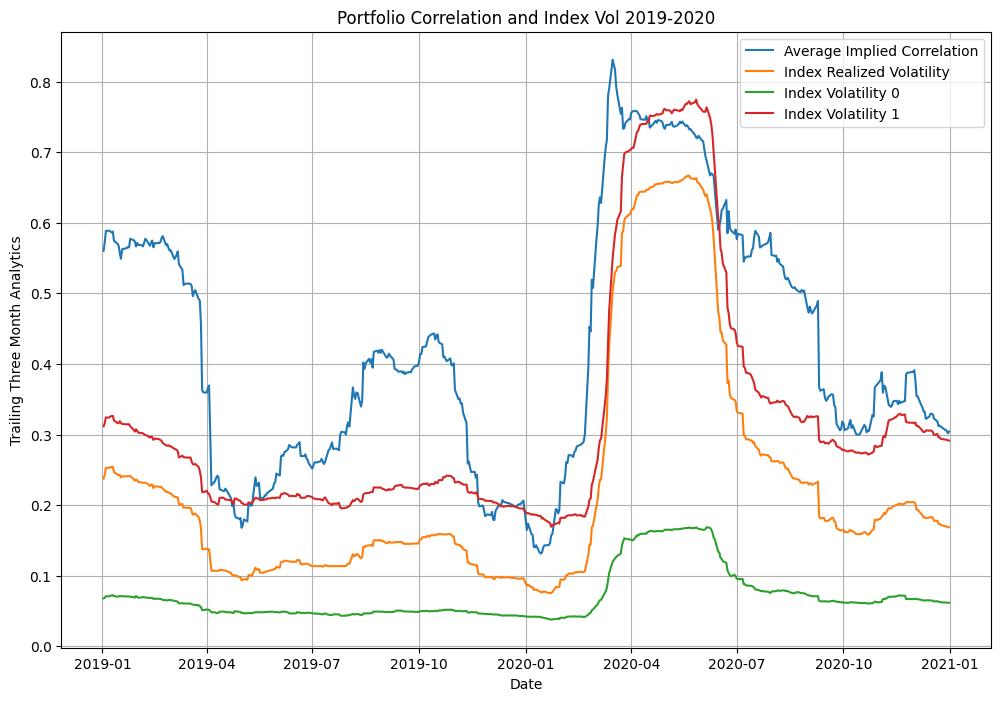

In [12]:
#2008-2009 Plot
plt.figure(figsize = (12,8))
plt.plot(index_0809["d"], index_0809["avg_corr"], label = "Average Implied Correlation")
plt.plot(index_0809["d"], index_0809["real_vol"], label = "Index Realized Volatility")
plt.plot(index_0809["d"], index_0809["vol_0"], label = "Index Volatility 0")
plt.plot(index_0809["d"], index_0809["vol_1"], label = "Index Volatility 1")
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Trailing Three Month Analytics")
plt.title("Portfolio Correlation and Index Vol 2008-2009")
plt.show()

#2019-2020 Plot
plt.figure(figsize = (12,8))
plt.plot(index_1920["d"], index_1920["avg_corr"], label = "Average Implied Correlation")
plt.plot(index_1920["d"], index_1920["real_vol"], label = "Index Realized Volatility")
plt.plot(index_1920["d"], index_1920["vol_0"], label = "Index Volatility 0")
plt.plot(index_1920["d"], index_1920["vol_1"], label = "Index Volatility 1")
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Trailing Three Month Analytics")
plt.title("Portfolio Correlation and Index Vol 2019-2020")
plt.show()

In [19]:
#4A
max_corr0809 = index_0809["avg_corr"].max()
max_date0809 = index_0809.loc[index_0809["avg_corr"].idxmax()]["d"]
print(f'2008-2009 Max Average Correlation of {max_corr0809} on {max_date0809}')

max_corr1920 = index_1920["avg_corr"].max()
max_date1920 = index_1920.loc[index_1920["avg_corr"].idxmax()]["d"]
print(f'2019-2020 Max Average Correlation of {max_corr1920} on {max_date1920}')

2008-2009 Max Average Correlation of 0.8095964230386969 on 2008-11-21 00:00:00
2019-2020 Max Average Correlation of 0.8308690820867729 on 2020-03-16 00:00:00
